# NS filter -- hardware validation

Trains per-RU Wiener taps from a pre-LR / HR frame pair, loads them onto the
FPGA, streams the frame through DMA, and verifies the hardware output against
the Python golden model (`ns_golden.py`), pixel-exact on the interior.

Runs across every uploaded test sequence. The primary claim is bit-exact
agreement between the FPGA and the golden model on the interior of every
frame -- outermost 3 rows and 3 cols are excluded because the golden uses
symmetric padding while the FPGA line buffer wraps into the next raster row
(different data at frame edges, same math everywhere else).


In [1]:
from pynq import Overlay, allocate
import pynq
import pynq.ps
setattr(pynq, 'ps', pynq.ps)
import pynq.lib.video
import numpy as np
import os, glob, time, gc

BASE     = '/home/xilinx/jupyter_notebooks/ns_filter'
DATASETS = '/home/xilinx/jupyter_notebooks/datasets'

ol  = Overlay(f'{BASE}/ns_filter_bd_wrapper.bit')
ns  = ol.ns_filter_0
dma = ol.axi_dma_0

# Fix for PYNQ start() hang -- DMA is already running after overlay load
dma.sendchannel._first_transfer = True
dma.recvchannel._first_transfer = True
print("overlay loaded")


overlay loaded


In [2]:
from ns_golden import NSGolden
g = NSGolden()
print(f"NSGolden ready ({g.K} basis columns, RU={g.RU_SIZE})")


NSGolden ready (12 basis columns, RU=256)


In [3]:
RESOLUTIONS = {
    'CrowdRun_1920x1080p50':               (1920, 1080),
    'Motorcycle_1920x1080_30fps_8bit':     (1920, 1080),
    'MountainBike_1920x1080_30fps_8bit':   (1920, 1080),
    'OldTownCross_1920x1080p50':           (1920, 1080),
    'PedestrianArea_1920x1080p25':         (1920, 1080),
    'Riverbed_1920x1080p25':               (1920, 1080),
    'RushFieldCuts_1920x1080_2997':        (1920, 1080),
    'TreesAndGrass_1920_1080_30fps_8bit':  (1920, 1080),
    'Vertical_Carnaby_1080x1920_5994':     (1080, 1920),
    'Vertical_bees_1080x1920_2997':        (1080, 1920),
    'WalkingInStreet_1920x1080_30fps':     (1080, 1920),
    'WorldCup_1920x1080_30p':              (1920, 1080),
    'WorldCup_far_1920x1080_30p':          (1920, 1080),
}

sequences = sorted(d for d in os.listdir(DATASETS)
                   if os.path.isdir(os.path.join(DATASETS, d)))
print(f"discovered {len(sequences)} sequences")
for s in sequences:
    tag = 'ok' if s in RESOLUTIONS else '?? unknown resolution'
    print(f"  {s:40s} {tag}")


discovered 13 sequences
  CrowdRun_1920x1080p50                    ok
  Motorcycle_1920x1080_30fps_8bit          ok
  MountainBike_1920x1080_30fps_8bit        ok
  OldTownCross_1920x1080p50                ok
  PedestrianArea_1920x1080p25              ok
  Riverbed_1920x1080p25                    ok
  RushFieldCuts_1920x1080_2997             ok
  TreesAndGrass_1920_1080_30fps_8bit       ok
  Vertical_Carnaby_1080x1920_5994          ok
  Vertical_bees_1080x1920_2997             ok
  WalkingInStreet_1920x1080_30fps          ok
  WorldCup_1920x1080_30p                   ok
  WorldCup_far_1920x1080_30p               ok


In [4]:
def load_raw_y(path, W, H):
    return np.fromfile(path, dtype=np.uint8).reshape(H, W)


def find_representative(seq_dir):
    """Return (prelr_path, hr_path, range_dir, frame_id, qp) for one usable
    pre-LR frame with a matching HR ground truth, or (None,)*5."""
    prelr_root = os.path.join(seq_dir, 'TEST_PRELR')
    hr_root    = os.path.join(seq_dir, 'TEST_HR')
    if not (os.path.isdir(prelr_root) and os.path.isdir(hr_root)):
        return (None,) * 5
    for rng in sorted(os.listdir(prelr_root)):
        prelr_dir = os.path.join(prelr_root, rng)
        if not os.path.isdir(prelr_dir):
            continue
        for f in sorted(os.listdir(prelr_dir)):
            if not f.endswith('_prelr.yuv'):
                continue
            parts    = f.replace('_prelr.yuv', '').split('_')
            frame_id = parts[1]
            qp       = parts[2].replace('qp', '')
            hr_path  = os.path.join(hr_root, f'frame_{frame_id}.y')
            if os.path.exists(hr_path):
                return os.path.join(prelr_dir, f), hr_path, rng, frame_id, qp
    return (None,) * 5


def reset_dma():
    mm = dma.mmio
    mm.write(0x00, 0x4); mm.write(0x30, 0x4); time.sleep(0.01)
    mm.write(0x00, 0x1); mm.write(0x30, 0x1)
    dma.sendchannel._first_transfer = True
    dma.recvchannel._first_transfer = True


def load_all_ru_taps(all_taps, all_norms, RU_ROWS, RU_COLS):
    """Write every RU's tap bank into the inactive side of the double-buffered
    tap_reg_file. Caller must pulse flip (0x3C bit 1) after this to make the
    freshly-loaded bank active."""
    for r in range(RU_ROWS):
        for c in range(RU_COLS):
            bank = r * 8 + c
            ns.write(0x3C, bank << 8)          # select inactive-bank slot
            for i in range(12):
                ns.write(i * 4, int(all_taps[bank][i]) & 0x7F)
            ns.write(0x30, int(all_norms[bank]) & 0xFFFF)


# Persistent CMA buffers, allocated ONCE and reused across every frame.
# Per-frame pynq.allocate()/freebuffer() churn fragments the CMA region and
# leaves DMA descriptors dangling at overlay teardown -> exit-time segfault.
# Sized for the largest frame we'll process (1920x1920 covers both landscape
# and portrait 1080p sources with headroom).
MAX_W, MAX_H = 1920, 1920
IN_BUF  = allocate(shape=(MAX_H * MAX_W,),         dtype=np.uint32)
OUT_BUF = allocate(shape=((MAX_H - 6) * MAX_W,),   dtype=np.uint32)
print(f"persistent buffers allocated: IN={IN_BUF.nbytes/1e6:.1f} MB, "
      f"OUT={OUT_BUF.nbytes/1e6:.1f} MB")


def run_fpga(prelr, W, H, timeout=5.0):
    """Stream a frame through the FPGA using the persistent buffers.

    Returns (filtered_frame, elapsed_ms). filtered_frame is shape (H-6, W).
    The FPGA emits H-6 rows (line buffer needs a 6-row fill before the first
    valid output). Output row R corresponds to frame center row R+3."""
    n_in  = H * W
    n_out = (H - 6) * W
    assert n_in  <= IN_BUF.size,  f"frame {W}x{H} exceeds IN_BUF capacity"
    assert n_out <= OUT_BUF.size, f"frame {W}x{H} exceeds OUT_BUF capacity"

    ns.write(0x34, W); ns.write(0x38, H)
    IN_BUF[:n_in] = prelr.flatten().astype(np.uint32)

    reset_dma()
    t0 = time.time()
    # Slice views share the same CMA memory -- no new allocation.
    dma.recvchannel.transfer(OUT_BUF[:n_out])
    ns.write(0x3C, 0x1)                       # start-of-frame pulse
    dma.sendchannel.transfer(IN_BUF[:n_in])

    while ((ns.read(0x04) >> 3) & 1) == 0:
        if time.time() - t0 > timeout:
            print(f"WARN: TLAST timeout, beats={ns.read(0x00)}")
            break
    time.sleep(0.05)
    dt = (time.time() - t0) * 1000

    filtered = (OUT_BUF[:n_out] & 0xFF).astype(np.uint8).copy().reshape(H - 6, W)
    return filtered, dt


persistent buffers allocated: IN=14.7 MB, OUT=14.7 MB


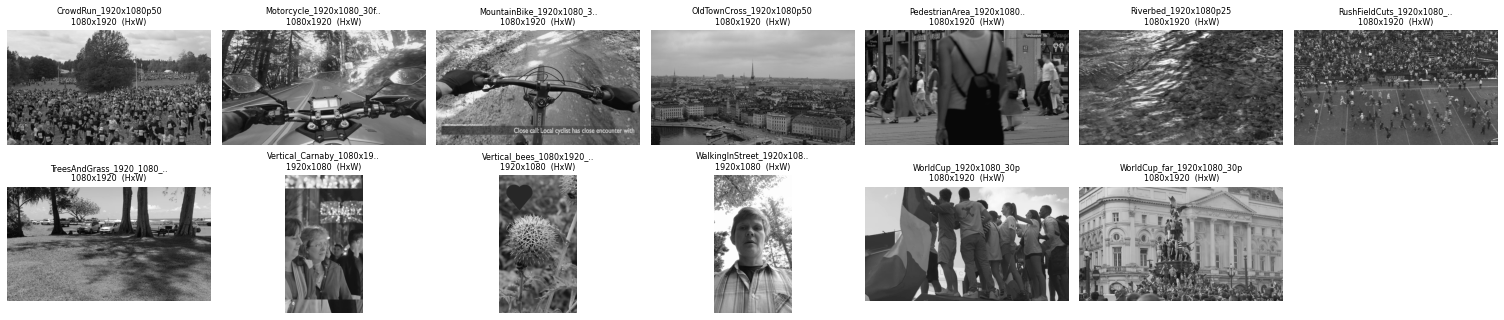

In [5]:
import matplotlib.pyplot as plt

n = len(sequences)
ncols = (n + 1) // 2
fig, axes = plt.subplots(2, ncols, figsize=(3 * ncols, 4.5))
axes = axes.flatten()

for i, name in enumerate(sequences):
    ax = axes[i]
    if name not in RESOLUTIONS:
        ax.axis('off'); continue
    W, H = RESOLUTIONS[name]
    p, _, _, _, _ = find_representative(os.path.join(DATASETS, name))
    if p is None:
        ax.axis('off'); continue
    img = load_raw_y(p, W, H)                     # img.shape = (H, W)
    ax.imshow(img, cmap='gray', aspect='equal')
    short = name if len(name) <= 26 else name[:24] + '..'
    ax.set_title(f'{short}\n{img.shape[0]}x{img.shape[1]}  (HxW)',
                 fontsize=8)
    ax.axis('off')

for j in range(len(sequences), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [6]:
# ---- Identity-tap sanity check (MUST give 100% before running the loop) ----
# Center tap = 32, all pair taps = 0, norm = 2048.  Nominal DC gain = 1.
# HW should reproduce input pixels exactly under the correct alignment.
example = next(s for s in sequences if s in RESOLUTIONS)
W, H = RESOLUTIONS[example]
p, _, _, _, _ = find_representative(os.path.join(DATASETS, example))
prelr = load_raw_y(p, W, H)

# 40 identity RU banks
RU_ROWS = (H + 255) // 256
RU_COLS = (W + 255) // 256
ident_taps  = [np.array([0]*11 + [32], dtype=np.int8)   for _ in range(RU_ROWS * RU_COLS)]
ident_norms = [2048]                                    * (RU_ROWS * RU_COLS)

load_all_ru_taps(ident_taps, ident_norms, RU_ROWS, RU_COLS)
ns.write(0x3C, 0x2)
hw, _ = run_fpga(prelr, W, H)

# Correct alignment: flat compare with start = 3*W + 3
start = 3 * W + 3
hw_flat = hw.flatten()
exp     = prelr.flatten()[start : start + hw_flat.size]
diff = hw_flat[:-20].astype(np.int16) - exp[:-20].astype(np.int16)
print(f"identity check on {example}:")
print(f"  max |diff|:  {int(np.abs(diff).max())}")
print(f"  mean |diff|: {float(np.abs(diff).mean()):.4f}")
print(f"  exact:       {float((diff==0).mean())*100:.2f}%")
print("  (expect max=0, mean=0.0000, exact=100.00% -- if not, alignment is off)")

del prelr, hw, hw_flat, exp, diff, ident_taps, ident_norms
gc.collect()


identity check on CrowdRun_1920x1080p50:
  max |diff|:  0
  mean |diff|: 0.0000
  exact:       100.00%
  (expect max=0, mean=0.0000, exact=100.00% -- if not, alignment is off)


30

In [7]:
# Reports TWO correctness numbers per sequence PLUS PSNR gain vs HR:
#   interior_exact: 2D compare on the algorithmic interior (excludes edge
#                   wrap region). Real correctness claim. Expect 100.00%.
#   flat_exact:     raster flat compare including edge wrap positions.
#                   Ceiling ~99.7% by design.
#   PSNR:           pre-LR vs HR (baseline) and HW vs HR (after filter),
#                   measured on the same interior slice for a fair delta.

import gc

def psnr(a, b):
    """PSNR in dB. Inputs uint8 or int, treated as uint8 range [0, 255]."""
    mse = float(np.mean((a.astype(np.int32) - b.astype(np.int32)) ** 2))
    return float('inf') if mse == 0 else 10.0 * np.log10(255.0 ** 2 / mse)

correctness = []   # (name, rng, frame_id, qp, mae_int, exact_int, exact_flat,
                   #  psnr_pre, psnr_hw)
skipped     = []

for name in sequences:
    if name not in RESOLUTIONS:
        skipped.append((name, 'unknown resolution')); continue
    W, H = RESOLUTIONS[name]
    seq_dir = os.path.join(DATASETS, name)

    prelr_path, hr_path, rng, frame_id, qp = find_representative(seq_dir)
    if prelr_path is None:
        skipped.append((name, 'no pre-LR / HR pair')); continue

    prelr = load_raw_y(prelr_path, W, H)
    hr    = load_raw_y(hr_path,    W, H)

    t0 = time.time()
    all_taps, all_norms = g.train(prelr, hr)
    train_dt = time.time() - t0

    RU_ROWS = (H + 255) // 256
    RU_COLS = (W + 255) // 256

    load_all_ru_taps(all_taps, all_norms, RU_ROWS, RU_COLS)
    ns.write(0x3C, 0x2)

    hw, hw_ms   = run_fpga(prelr, W, H)                # (H-6, W)
    gold_full   = g.apply(prelr, all_taps, all_norms)  # (H, W)

    # ---- Interior 2D compare (HW vs golden) ----
    # hw[R, C] == gold_full[R+3, C+3] for C in [0, W-4].
    gi = gold_full[3:H - 3, 3:W - 3].astype(np.int16)   # (H-6, W-6)
    fi = hw[:, 0:W - 6].astype(np.int16)                # (H-6, W-6)
    diff_int   = gi - fi
    mae_int    = float(np.abs(diff_int).mean())
    exact_int  = float((diff_int == 0).mean()) * 100

    # ---- Flat compare (HW vs golden, includes wrap) ----
    start   = 3 * W + 3
    hw_flat = hw.flatten()
    gf_flat = gold_full.flatten()
    exp     = gf_flat[start : start + hw_flat.size]
    diff_flat  = hw_flat[:-20].astype(np.int16) - exp[:-20].astype(np.int16)
    exact_flat = float((diff_flat == 0).mean()) * 100

    # ---- PSNR vs HR (algorithmic quality) ----
    # Compare on the exact same interior slice used for correctness so the
    # baseline and filtered numbers are on identical pixel sets.
    hr_int    = hr[3:H - 3, 3:W - 3].astype(np.int16)
    prelr_int = prelr[3:H - 3, 3:W - 3].astype(np.int16)
    hw_int    = hw[:, 0:W - 6].astype(np.int16)
    psnr_pre  = psnr(prelr_int, hr_int)
    psnr_hw   = psnr(hw_int,    hr_int)

    correctness.append((name, rng, frame_id, qp, mae_int,
                        exact_int, exact_flat, psnr_pre, psnr_hw))
    print(f"{name:38s} {frame_id} qp{qp}  train={train_dt:5.1f}s  "
          f"hw={hw_ms:4.0f}ms  int={exact_int:7.3f}%  flat={exact_flat:5.2f}%  "
          f"PSNR pre={psnr_pre:5.2f}dB  hw={psnr_hw:5.2f}dB  "
          f"(+{psnr_hw - psnr_pre:.2f})")

    del prelr, hr, hw, gold_full, gi, fi, diff_int
    del hw_flat, gf_flat, exp, diff_flat
    del hr_int, prelr_int, hw_int, all_taps, all_norms
    gc.collect()

print(f"\ndone. {len(correctness)} sequences ran, {len(skipped)} skipped.")
for s, reason in skipped:
    print(f"  skipped {s}: {reason}")


CrowdRun_1920x1080p50                  013 qp110  train= 32.5s  hw=  85ms  int=100.000%  flat=99.87%  PSNR pre=37.38dB  hw=37.47dB  (+0.09)
Motorcycle_1920x1080_30fps_8bit        013 qp110  train= 32.8s  hw=  84ms  int=100.000%  flat=99.82%  PSNR pre=39.82dB  hw=39.85dB  (+0.03)
MountainBike_1920x1080_30fps_8bit      013 qp110  train= 32.6s  hw=  84ms  int=100.000%  flat=99.82%  PSNR pre=40.16dB  hw=40.27dB  (+0.11)
OldTownCross_1920x1080p50              013 qp110  train= 32.7s  hw=  84ms  int=100.000%  flat=99.85%  PSNR pre=36.82dB  hw=36.87dB  (+0.05)
PedestrianArea_1920x1080p25            013 qp110  train= 33.7s  hw=  84ms  int=100.000%  flat=99.93%  PSNR pre=41.90dB  hw=41.96dB  (+0.07)
Riverbed_1920x1080p25                  013 qp110  train= 32.7s  hw=  84ms  int=100.000%  flat=99.91%  PSNR pre=40.07dB  hw=40.17dB  (+0.10)
RushFieldCuts_1920x1080_2997           013 qp110  train= 32.6s  hw=  84ms  int=100.000%  flat=99.94%  PSNR pre=40.16dB  hw=40.22dB  (+0.05)
TreesAndGrass_1920_1

In [8]:
exacts_int  = [c[5] for c in correctness]
exacts_flat = [c[6] for c in correctness]
maes_int    = [c[4] for c in correctness]
psnrs_pre   = [c[7] for c in correctness]
psnrs_hw    = [c[8] for c in correctness]
gains       = [h - p for p, h in zip(psnrs_pre, psnrs_hw)]

print("=" * 92)
print(f"Sequences checked         : {len(correctness)} / {len(sequences)}")
print(f"Mean interior exact-match : {np.mean(exacts_int):7.3f}%  "
      f"(worst {min(exacts_int):.3f}%)")
print(f"Mean flat exact-match     : {np.mean(exacts_flat):7.3f}%  "
      f"(ceiling ~99.7% by design; HW edge wrap vs golden symmetric padding)")
print(f"Mean interior MAE         : {np.mean(maes_int):.4f}")
print(f"Mean PSNR pre-LR vs HR    : {np.mean(psnrs_pre):6.3f} dB")
print(f"Mean PSNR FPGA  vs HR     : {np.mean(psnrs_hw):6.3f} dB")
print(f"Mean PSNR gain            : {np.mean(gains):+6.3f} dB")
print("=" * 92)

print(f"\n{'Sequence':40s} {'Frame':>6s} {'QP':>4s} "
      f"{'Interior%':>10s} {'Flat%':>7s} "
      f"{'PSNR_pre':>9s} {'PSNR_hw':>9s} {'dPSNR':>7s}")
for name, rng, frame_id, qp, mae_int, ei, ef, pp, ph in correctness:
    print(f"{name:40s} {frame_id:>6s} {qp:>4s} "
          f"{ei:10.4f} {ef:7.2f} "
          f"{pp:9.3f} {ph:9.3f} {ph - pp:+7.3f}")


Sequences checked         : 13 / 13
Mean interior exact-match : 100.000%  (worst 100.000%)
Mean flat exact-match     :  99.830%  (ceiling ~99.7% by design; HW edge wrap vs golden symmetric padding)
Mean interior MAE         : 0.0000
Mean PSNR pre-LR vs HR    : 40.472 dB
Mean PSNR FPGA  vs HR     : 40.558 dB
Mean PSNR gain            : +0.086 dB

Sequence                                  Frame   QP  Interior%   Flat%  PSNR_pre   PSNR_hw   dPSNR
CrowdRun_1920x1080p50                       013  110   100.0000   99.87    37.382    37.473  +0.090
Motorcycle_1920x1080_30fps_8bit             013  110   100.0000   99.82    39.820    39.851  +0.031
MountainBike_1920x1080_30fps_8bit           013  110   100.0000   99.82    40.163    40.270  +0.107
OldTownCross_1920x1080p50                   013  110   100.0000   99.85    36.821    36.872  +0.051
PedestrianArea_1920x1080p25                 013  110   100.0000   99.93    41.896    41.963  +0.068
Riverbed_1920x1080p25                       013  110

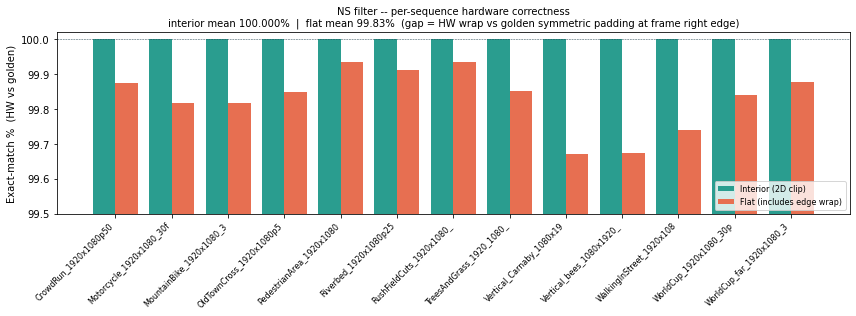

In [9]:
names       = [c[0][:24] for c in correctness]
exacts_int  = [c[5] for c in correctness]
exacts_flat = [c[6] for c in correctness]

fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(len(names))
ax.bar(x - 0.2, exacts_int,  width=0.4, color='#2a9d8f',
       label='Interior (2D clip)')
ax.bar(x + 0.2, exacts_flat, width=0.4, color='#e76f51',
       label='Flat (includes edge wrap)')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Exact-match %  (HW vs golden)')
ax.set_ylim(min(99.5, min(exacts_flat) - 0.05), 100.02)
ax.axhline(100.0, color='#264653', linestyle='--', linewidth=0.5)
ax.set_title(f'NS filter -- per-sequence hardware correctness\n'
             f'interior mean {np.mean(exacts_int):.3f}%  |  '
             f'flat mean {np.mean(exacts_flat):.2f}%  '
             f'(gap = HW wrap vs golden symmetric padding at frame right edge)',
             fontsize=10)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


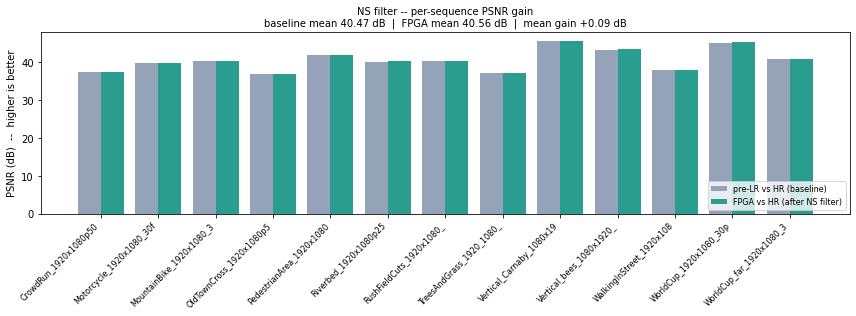

In [10]:
# Second chart: PSNR gain from the filter (pre-LR vs HW, both vs HR).
names     = [c[0][:24] for c in correctness]
psnrs_pre = [c[7] for c in correctness]
psnrs_hw  = [c[8] for c in correctness]

fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(len(names))
ax.bar(x - 0.2, psnrs_pre, width=0.4, color='#94a3b8', label='pre-LR vs HR (baseline)')
ax.bar(x + 0.2, psnrs_hw,  width=0.4, color='#2a9d8f', label='FPGA vs HR (after NS filter)')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('PSNR (dB)  --  higher is better')
gains = [h - p for p, h in zip(psnrs_pre, psnrs_hw)]
ax.set_title(f'NS filter -- per-sequence PSNR gain\n'
             f'baseline mean {np.mean(psnrs_pre):.2f} dB  |  '
             f'FPGA mean {np.mean(psnrs_hw):.2f} dB  |  '
             f'mean gain {np.mean(gains):+.2f} dB',
             fontsize=10)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


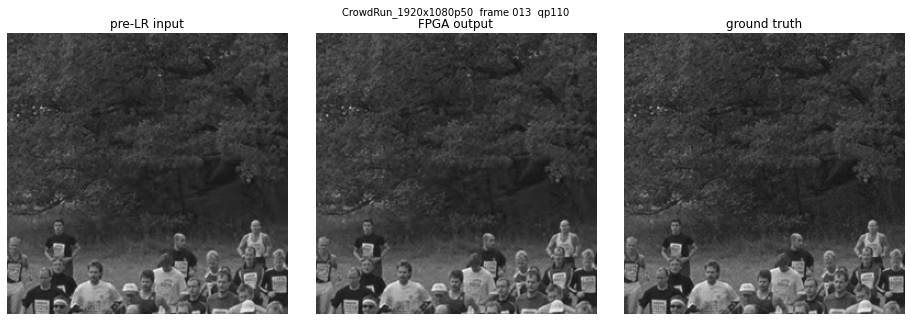

In [11]:
# Qualitative example — pre-LR vs FPGA vs HR for a mid-frame crop.
# Using the correct 2D alignment: hw[R, C] displays as golden position (R+3, C+3)
# (mid-frame is far from the row-wrap at C >= W-3, so we ignore that here).
example = correctness[0][0]
W, H = RESOLUTIONS[example]
seq_dir = os.path.join(DATASETS, example)
prelr_path, hr_path, _, frame_id, qp = find_representative(seq_dir)
prelr = load_raw_y(prelr_path, W, H)
hr    = load_raw_y(hr_path,    W, H)

all_taps, all_norms = g.train(prelr, hr)
RU_ROWS = (H + 255) // 256
RU_COLS = (W + 255) // 256
load_all_ru_taps(all_taps, all_norms, RU_ROWS, RU_COLS)
ns.write(0x3C, 0x2)
hw, _ = run_fpga(prelr, W, H)

# Golden crop: rows r0..r1, cols c0..c1
# HW crop that corresponds: rows r0-3..r1-3, cols c0-3..c1-3
r0, r1 = 400, 656
c0, c1 = 700, 956
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(prelr[r0:r1, c0:c1], cmap='gray', vmin=0, vmax=255)
axes[0].set_title('pre-LR input');   axes[0].axis('off')
axes[1].imshow(hw[r0 - 3:r1 - 3, c0 - 3:c1 - 3], cmap='gray', vmin=0, vmax=255)
axes[1].set_title('FPGA output');    axes[1].axis('off')
axes[2].imshow(hr[r0:r1, c0:c1], cmap='gray', vmin=0, vmax=255)
axes[2].set_title('ground truth');   axes[2].axis('off')
plt.suptitle(f'{example}  frame {frame_id}  qp{qp}', fontsize=10)
plt.tight_layout()
plt.show()


In [12]:
# Explicit teardown -- order matters. Free the persistent CMA buffers BEFORE
# the overlay object goes out of scope, so PYNQ's DMA descriptor cleanup runs
# while the buffers still exist. Skipping this is what causes the exit-time
# segfault in Zynq's ZOCL driver.
try:
    IN_BUF.freebuffer()
    OUT_BUF.freebuffer()
    print("CMA buffers freed")
except Exception as e:
    print(f"buffer free skipped: {e}")

try:
    ol.free()
    print("overlay released")
except Exception as e:
    print(f"overlay free skipped: {e}")

print("done.")


CMA buffers freed
overlay released
done.
